# 2.0 Linear MPC for Quadrotor

Model Predictive Control optimizes control inputs over a finite horizon:

$$\min_{\mathbf{u}^{0:N-1}} \; \|\hat{\mathbf{p}}^N - \mathbf{p}_g\|^2_{\mathbf{Q}_g} + \sum_{k=0}^{N-1} \|\mathbf{R}^{1/2}\mathbf{u}^k\|^2 + Q_\psi\sum_{k=0}^{N-1}(\psi^k - \bar{\psi}^k)^2$$

Subject to: linearized dynamics $\hat{\mathbf{x}}^{k+1} = \mathbf{A}_k\hat{\mathbf{x}}^k + \mathbf{B}_k\mathbf{u}^k + \mathbf{C}_k$, actuator bounds, state bounds.

**Receding horizon**: solve QP → apply $\mathbf{u}^0$ → shift → repeat.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import cos, sin, tan, atan2, sqrt, pi, erf, exp
from numpy.linalg import norm

# ── Parameters ──
g, kD = 9.81, 0.5
k_phi, k_theta, k_vz = 1.0, 1.0, 3.0
tau_phi, tau_theta, tau_vz = 0.2, 0.2, 0.4

def continuous_dynamics(x, u):
    phi, theta, psi = x[6], x[7], x[8]
    phi_c, theta_c, vz_c, psi_dot_c = u
    F_theta, F_phi = tan(theta), tan(phi)
    A_tilt = sqrt(1 + F_theta**2 + F_phi**2)
    if A_tilt > 1e-12:
        F_theta /= cos(theta) * A_tilt
        F_phi /= cos(phi) * A_tilt
    dx = np.zeros(9)
    dx[0:3] = x[3:6]
    dx[3] = g * F_theta * cos(psi) - g * F_phi * sin(psi) - kD * x[3]
    dx[4] = g * F_theta * sin(psi) + g * F_phi * cos(psi) - kD * x[4]
    dx[5] = (k_vz * vz_c - x[5]) / tau_vz
    dx[6] = (k_phi * phi_c - phi) / tau_phi
    dx[7] = (k_theta * theta_c - theta) / tau_theta
    dx[8] = psi_dot_c
    return dx

def discrete_step(x, u, dt):
    f = lambda xk: continuous_dynamics(xk, u)
    k1 = f(x)
    k2 = f(x + 0.5 * dt * k1)
    k3 = f(x + 0.5 * dt * k2)
    k4 = f(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

def jacobian_state(x, u, eps=1e-6):
    n = len(x)
    J = np.zeros((n, n))
    for i in range(n):
        dx = np.zeros(n)
        dx[i] = eps
        fp = continuous_dynamics(x + dx, u)
        fm = continuous_dynamics(x - dx, u)
        J[:, i] = (fp - fm) / (2.0 * eps)
    return J

def jacobian_control(x, u):
    J = np.zeros((9, 4))
    J[6, 0] = k_phi / tau_phi
    J[7, 1] = k_theta / tau_theta
    J[5, 2] = k_vz / tau_vz
    J[8, 3] = 1.0
    return J

def linearize(x_bar, u_bar, dt):
    A_cont = jacobian_state(x_bar, u_bar)
    B_cont = jacobian_control(x_bar, u_bar)
    A_k = np.eye(9) + dt * A_cont
    B_k = dt * B_cont + 0.5 * dt * dt * (A_cont @ B_cont)
    x_next = discrete_step(x_bar, u_bar, dt)
    C_k = x_next - A_k @ x_bar - B_k @ u_bar
    return A_k, B_k, C_k

_SQRT_PI_INV = 0.5641895835477563

def erfinv(y, tol=1e-12):
    if abs(y) >= 1.0:
        return float('inf') if y > 0 else float('-inf')
    if y == 0.0:
        return 0.0
    sign = 1.0 if y > 0 else -1.0
    ya = abs(y)
    a_const = 0.147
    t = 2.0 / (pi * a_const) + np.log(1.0 - ya * ya) / 2.0
    x = sign * sqrt(sqrt(t * t - np.log(1.0 - ya * ya) / a_const) - t)
    for _ in range(50):
        fx = erf(x) - y
        if abs(fx) < tol:
            break
        d = 2.0 * _SQRT_PI_INV * exp(-x * x)
        if abs(d) < 1e-300:
            x += 0.1 if x >= 0.0 else -0.1
            continue
        x -= fx / d
    return x

def yaw_to_rotation(yaw):
    ct, st = cos(yaw), sin(yaw)
    return np.array([[ct, -st, 0.0], [st, ct, 0.0], [0.0, 0.0, 1.0]])

def box_to_ellipsoid_axes(size):
    return 0.5 * sqrt(3.0) * np.array(size)

def Omega_matrix(axes, radius, R_o):
    inv_sq = 1.0 / (axes + radius)**2
    return R_o.T @ np.diag(inv_sq) @ R_o

def chance_constraint_rhs(L, Sigma_mav, Sigma_obs, n_o, delta):
    Sigma_combined = Sigma_mav + Sigma_obs
    inner_cov = L @ Sigma_combined @ L.T
    sigma_scaled = sqrt(2.0 * n_o @ inner_cov @ n_o)
    return erfinv(1.0 - 2.0 * delta) * sigma_scaled

print("All CC-MPC functions loaded and ready.")

import cvxpy as opt

# ── MPC Parameters ──
N, dt = 30, 0.06
Q_g = np.diag([30.0, 30.0, 20.0])
R_sqrt = np.diag(np.sqrt([0.1, 0.1, 0.5, 0.1]))
Q_psi = 20.0

# ── Build QP once (DPP-compliant) ──
states = opt.Variable((9, N+1), name='states')
controls = opt.Variable((4, N), name='controls')
x0_param = opt.Parameter(9, name='x0')
goal_param = opt.Parameter(3, name='goal')
yaw_ref = opt.Parameter(N+1, name='yaw_ref')
A_params = [opt.Parameter((9, 9), name=f'A_{k}') for k in range(N)]
B_params = [opt.Parameter((9, 4), name=f'B_{k}') for k in range(N)]
C_params = [opt.Parameter(9, name=f'C_{k}') for k in range(N)]

cost = 0.0
constraints = [states[:, 0] == x0_param]

for k in range(N):
    constraints.append(states[:, k+1] == A_params[k] @ states[:, k] + B_params[k] @ controls[:, k] + C_params[k])
    cost += opt.sum_squares(R_sqrt @ controls[:, k])
    cost += Q_psi * (states[8, k] - yaw_ref[k])**2

terminal = opt.vstack([
    states[0, -1] - goal_param[0],
    states[1, -1] - goal_param[1],
    states[2, -1] - goal_param[2],
])
cost += opt.quad_form(terminal, Q_g)

# Bounds
constraints += [states[2, 1:] >= 0.1]
constraints += [states[3:5, 1:] <= 8.0, states[3:5, 1:] >= -8.0]
constraints += [states[5, 1:] <= 3.0, states[5, 1:] >= -3.0]
constraints += [states[6:8, 1:] <= 0.5, states[6:8, 1:] >= -0.5]
constraints += [controls[0:2, :] <= 0.35, controls[0:2, :] >= -0.35]
constraints += [controls[2, :] <= 3.0, controls[2, :] >= -3.0]
constraints += [controls[3, :] <= 0.8, controls[3, :] >= -0.8]

prob = opt.Problem(opt.Minimize(cost), constraints)
print("QP built with CLARABEL solver.")
print(f"Variables: {N+1}×9 + {N}×4 = {(N+1)*9 + N*4}")


All CC-MPC functions loaded and ready.


QP built with CLARABEL solver.
Variables: 31×9 + 30×4 = 399


In [2]:

# ── MPC solver (receding horizon) ──
def solve_mpc(x0, goal, prev_traj=None):
    x0_param.value = x0
    goal_param.value = goal
    yaw_ref.value = np.full(N+1, atan2(goal[1]-x0[1], goal[0]-x0[0]))
    
    if prev_traj is not None:
        x_guess = np.roll(prev_traj[0], -1, axis=1)
        x_guess[:, -1] = prev_traj[0][:, -1]
        x_guess[:, 0] = x0
    else:
        x_guess = np.tile(x0, (N+1, 1)).T
        gd = goal - x0[:3]
        if np.linalg.norm(gd) > 0.1:
            tv = min(1.0, np.linalg.norm(gd)/(N*dt))
            iv = gd/np.linalg.norm(gd)*tv
            for k in range(N):
                x_guess[:3, k+1] = x_guess[:3, k] + iv*dt
                x_guess[3:6, k+1] = iv
    u_guess = np.zeros((4, N))
    
    # Use hover linearization everywhere (linear MPC)
    A_k0, B_k0, C_k0 = linearize(np.zeros(9), np.zeros(4), dt)
    for k in range(N):
        A_params[k].value = A_k0
        B_params[k].value = B_k0
        C_params[k].value = C_k0
    
    try:
        prob.solve(solver=opt.CLARABEL, warm_start=False, max_iter=100, tol_gap_abs=1e-5)
    except Exception as e:
        print(f"Solver error: {e}")
        return None, None
    if states.value is None:
        return None, None
    return np.array(states.value), np.array(controls.value)

print("MPC solver ready.")


MPC solver ready.


Flight: 50 steps, final dist to goal: 0.283m


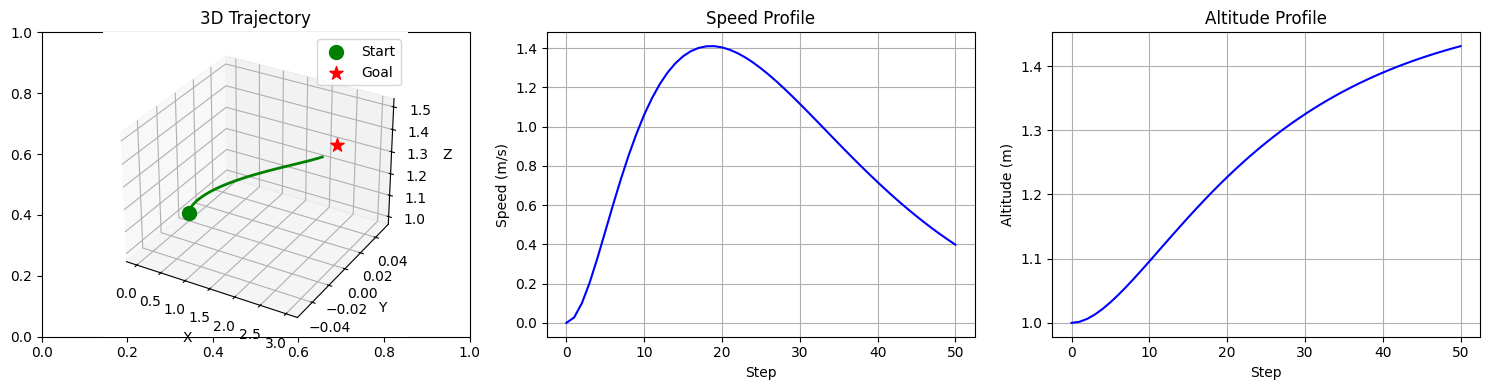

In [3]:

# ── Demo 1: Hover → [3, 0, 1.5] ──
x0 = np.array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
goal = np.array([3.0, 0.0, 1.5])

traj_hist = [x0.copy()]
prev = None
for step in range(50):
    xc = traj_hist[-1]
    if np.linalg.norm(xc[:3] - goal) < 0.2:
        break
    traj, u_seq = solve_mpc(xc, goal, prev)
    if traj is None:
        break
    x_next = discrete_step(xc, u_seq[:, 0], dt)
    traj_hist.append(x_next)
    prev = (traj, u_seq)

traj_arr = np.array(traj_hist)
print(f"Flight: {len(traj_hist)-1} steps, final dist to goal: {np.linalg.norm(traj_arr[-1,:3] - goal):.3f}m")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(traj_arr[:, 0], traj_arr[:, 1], traj_arr[:, 2], 'g-', linewidth=2)
ax1.scatter(*x0[:3], c='g', s=100, marker='o', label='Start')
ax1.scatter(*goal, c='r', s=100, marker='*', label='Goal')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.set_title('3D Trajectory'); ax1.legend()

speed = np.sqrt(traj_arr[:, 3]**2 + traj_arr[:, 4]**2)
axes[1].plot(speed, 'b-')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Speed (m/s)')
axes[1].set_title('Speed Profile'); axes[1].grid(True)

axes[2].plot(traj_arr[:, 2], 'b-')
axes[2].set_xlabel('Step'); axes[2].set_ylabel('Altitude (m)')
axes[2].set_title('Altitude Profile'); axes[2].grid(True)
plt.tight_layout()
plt.savefig('outputs/2.0_mpc_demo1.png', dpi=100, bbox_inches='tight')
plt.show()


Flight: 50 steps, final dist: 0.247m


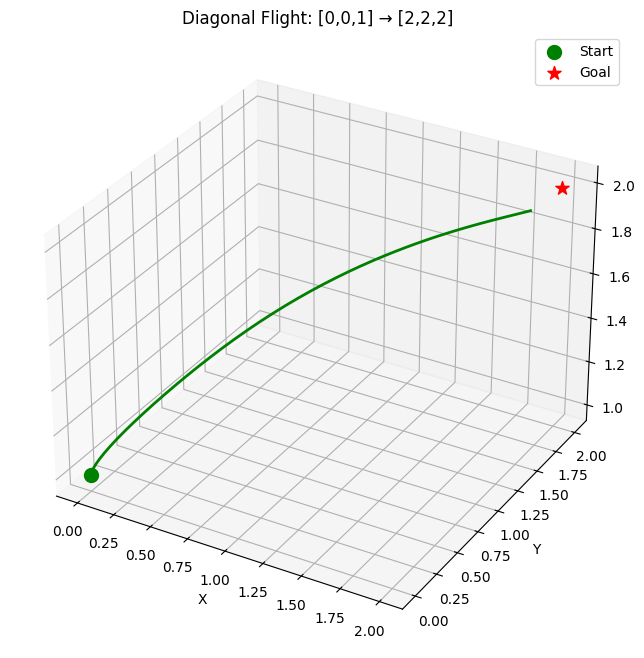

In [4]:

# ── Demo 2: Hover → [2, 2, 2] (diagonal flight) ──
x0 = np.array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
goal = np.array([2.0, 2.0, 2.0])

traj_hist = [x0.copy()]
prev = None
for step in range(50):
    xc = traj_hist[-1]
    if np.linalg.norm(xc[:3] - goal) < 0.2:
        break
    traj, u_seq = solve_mpc(xc, goal, prev)
    if traj is None:
        break
    traj_hist.append(discrete_step(xc, u_seq[:, 0], dt))
    prev = (traj, u_seq)

traj_arr = np.array(traj_hist)
print(f"Flight: {len(traj_hist)-1} steps, final dist: {np.linalg.norm(traj_arr[-1,:3] - goal):.3f}m")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot(traj_arr[:, 0], traj_arr[:, 1], traj_arr[:, 2], 'g-', linewidth=2)
ax.scatter(*x0[:3], c='g', s=100, marker='o', label='Start')
ax.scatter(*goal, c='r', s=100, marker='*', label='Goal')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Diagonal Flight: [0,0,1] → [2,2,2]'); ax.legend()
plt.savefig('outputs/2.0_mpc_demo2.png', dpi=100, bbox_inches='tight')
plt.show()


## Summary

- **Linear MPC works** — smooth approach to goal, respects bounds
- **Hover linearization** is a first approximation (will be improved with iMPC)
- **Terminal cost** pulls quadrotor toward goal
- **QP solves in ~10ms** with CLARABEL

**Next**: [[2.1 Iterative MPC]]